# Generating Synthetic Data (Sim2Real Strategy)

This notebook is used to generate training and validation sets for KalmanNet.
Data is generated based on statistics from a real trajectory (`data.mat`) so the model learns on data as close to reality as possible.

**Key features:**
- Resampling speeds and angular velocities from real data (preserving correlation).
- Trajectory smoothing (Inertia).
- Validation using UKF (Filtering out physically nonsensical trajectories or those too difficult for the filter).
- Generating data with bias and noise, but validating on data without bias.

In [1]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Robust path finding for data.mat
current_path = Path.cwd()
possible_data_paths = [
    current_path / 'data' / 'data.mat',
    current_path.parent / 'data' / 'data.mat',
    current_path.parent.parent / 'data' / 'data.mat',
    # Fallback absolute path
    Path('/home/luky/skola/KalmanNet-for-state-estimation/data/data.mat')
]

dataset_path = None
for p in possible_data_paths:
    if p.exists():
        dataset_path = p
        break

if dataset_path is None or not dataset_path.exists():
    print("Warning: data.mat not found automatically.")
    dataset_path = Path('data/data.mat')

print(f"Dataset path: {dataset_path}")

# Add project root to sys.path (2 levels up from debug/test)
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root added: {project_root}")
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import random
from tqdm import tqdm
import shutil
import Filters
from Systems import DynamicSystemTAN
import torch.nn.functional as func


Dataset path: /home/luky/skola/KalmanNet-main/data/data.mat
Project root added: /home/luky/skola/KalmanNet-main


In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
mat_data = loadmat(dataset_path)

souradniceX_mapa = mat_data['souradniceX']
souradniceY_mapa = mat_data['souradniceY']
souradniceZ_mapa = mat_data['souradniceZ']
souradniceGNSS = mat_data['souradniceGNSS'] 
x_axis_unique = souradniceX_mapa[0, :]
y_axis_unique = souradniceY_mapa[:, 0]

print(f"Map X: {x_axis_unique.shape}, Y: {y_axis_unique.shape}, Z: {souradniceZ_mapa.shape}")

terMap_interpolator = RegularGridInterpolator(
    (y_axis_unique, x_axis_unique),
    souradniceZ_mapa,
    bounds_error=False, 
    fill_value=np.nan
)

Map X: (2500,), Y: (2500,), Z: (2500, 2500)


In [4]:
state_dim = 4
obs_dim = 3
dT = 1
q = 1

F = torch.tensor([[1.0, 0.0, dT, 0.0],
                   [0.0, 1.0, 0.0, dT],
                   [0.0, 0.0, 1.0, 0.0],
                   [0.0, 0.0, 0.0, 1.0]])

Q = q* torch.tensor([[dT**3/3, 0.0, dT**2/2, 0.0],
                   [0.0, dT**3/3, 0.0, dT**2/2],
                   [dT**2/2, 0.0, dT, 0.0],
                   [0.0, dT**2/2, 0.0, dT]])
R = torch.tensor([[3.0**2, 0.0, 0.0],
                   [0.0, 1.0**2, 0.0],
                   [0.0, 0.0, 1.0**2]])

initial_velocity = torch.from_numpy(np.array([0,0]))
initial_position = torch.from_numpy(souradniceGNSS[:2, 0])
x_0 = torch.cat([
    initial_position,
    initial_velocity
]).float()

P_0 = torch.tensor([[25.0, 0.0, 0.0, 0.0],
                    [0.0, 25.0, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5]])

def h_nl_differentiable(x: torch.Tensor, map_tensor, x_min, x_max, y_min, y_max) -> torch.Tensor:
    batch_size = x.shape[0]

    px = x[:, 0]
    py = x[:, 1]

    px_norm = 2.0 * (px - x_min) / (x_max - x_min) - 1.0
    py_norm = 2.0 * (py - y_min) / (y_max - y_min) - 1.0

    sampling_grid = torch.stack((px_norm, py_norm), dim=1).view(batch_size, 1, 1, 2)

    vyska_terenu_batch = func.grid_sample(
        map_tensor.expand(batch_size, -1, -1, -1),
        sampling_grid, 
        mode='bilinear', 
        padding_mode='border',
        align_corners=True
    )

    vyska_terenu = vyska_terenu_batch.view(batch_size)

    vx_w = x[:, 2]
    vy_w = x[:, 3]

    result = torch.stack([vyska_terenu, vx_w, vy_w], dim=1)
    
    return result

terMap_tensor = torch.from_numpy(souradniceZ_mapa).float().unsqueeze(0).unsqueeze(0).to(device)
x_min, x_max = x_axis_unique.min(), x_axis_unique.max()
y_min, y_max = y_axis_unique.min(), y_axis_unique.max()

h_wrapper = lambda x: h_nl_differentiable(
    x, 
    map_tensor=terMap_tensor, 
    x_min=x_min, 
    x_max=x_max, 
    y_min=y_min, 
    y_max=y_max
)

system_model = DynamicSystemTAN(
    state_dim=state_dim,
    obs_dim=obs_dim,
    Q=Q.float(),
    R=R.float(),
    Ex0=x_0.float(),
    P0=P_0.float(),
    F=F.float(),
    h=h_wrapper,
    x_axis_unique=x_axis_unique, 
    y_axis_unique=y_axis_unique,
    device=device
)

print("System Model Initialized")

INFO: DynamicSystemTAN inicializován s hranicemi mapy:
  X: [1476611.42, 1489541.47]
  Y: [6384032.63, 6400441.34]
System Model Initialized


In [5]:
def extract_driving_stats(real_traj_tensor):
    positions = real_traj_tensor[:, :2]
    deltas = positions[1:] - positions[:-1]
    speeds = torch.norm(deltas, dim=1)
    headings = torch.atan2(deltas[:, 1], deltas[:, 0])
    yaw_rates = headings[1:] - headings[:-1]
    yaw_rates = (yaw_rates + np.pi) % (2 * np.pi) - np.pi
    speeds = speeds[:-1]
    
    valid_mask = (torch.isfinite(speeds) & torch.isfinite(yaw_rates) & (speeds > 0.5))
    clean_speeds = speeds[valid_mask]
    clean_yaw_rates = yaw_rates[valid_mask]
    
    print(f"✅ Statistika: {len(clean_speeds)} vzorků. AvgSpeed: {clean_speeds.mean():.2f} m/s")
    return clean_speeds, clean_yaw_rates

real_traj_np = souradniceGNSS[:2, :].T 
real_traj_tensor = torch.from_numpy(real_traj_np).float().to(device)
real_speeds, real_yaws = extract_driving_stats(real_traj_tensor)

✅ Statistika: 1263 vzorků. AvgSpeed: 26.76 m/s


In [6]:
def simulate_batch_ackermann(system, batch_size, seq_len, stats_speeds, stats_yaws, speed_scale=0.99):
    device = system.Ex0.device
    dt = 1.0
    
    margin = 150.0
    x_min, x_max = system.min_x + margin, system.max_x - margin
    y_min, y_max = system.min_y + margin, system.max_y - margin
    
    start_x = (torch.rand(batch_size, 1, device=device) * (x_max - x_min)) + x_min
    start_y = (torch.rand(batch_size, 1, device=device) * (y_max - y_min)) + y_min
    start_psi = (torch.rand(batch_size, 1, device=device) * 2 * np.pi) - np.pi
    
    rand_idx = torch.randint(0, len(stats_speeds), (batch_size, seq_len), device=device)
    chosen_v = stats_speeds[rand_idx] * speed_scale
    chosen_omega = stats_yaws[rand_idx]
    
    alpha_v = 0.3      
    alpha_omega = 0.4  
    
    smooth_v = torch.zeros_like(chosen_v)
    smooth_omega = torch.zeros_like(chosen_omega)
    
    curr_v = chosen_v[:, 0]
    curr_omega = chosen_omega[:, 0]
    
    for t in range(seq_len):
        curr_v = (1 - alpha_v) * curr_v + alpha_v * chosen_v[:, t]
        curr_omega = (1 - alpha_omega) * curr_omega + alpha_omega * chosen_omega[:, t]
        smooth_v[:, t] = curr_v
        smooth_omega[:, t] = curr_omega
        
    traj_x = []
    traj_y = []
    traj_vx = []
    traj_vy = []
    
    curr_x, curr_y, curr_psi = start_x.squeeze(), start_y.squeeze(), start_psi.squeeze()
    
    q_std_v = 0.2
    q_std_omega = 0.1
    
    for t in range(seq_len):
        v_cmd = smooth_v[:, t]
        omega_cmd = smooth_omega[:, t]
        
        noise_v = torch.randn_like(v_cmd) * q_std_v
        noise_omega = torch.randn_like(omega_cmd) * q_std_omega
        
        v_real = v_cmd + noise_v
        omega_real = omega_cmd + noise_omega

        vx = v_real * torch.cos(curr_psi)
        vy = v_real * torch.sin(curr_psi)
        
        traj_x.append(curr_x)
        traj_y.append(curr_y)
        traj_vx.append(vx)
        traj_vy.append(vy)

        curr_x = curr_x + vx * dt
        curr_y = curr_y + vy * dt
        curr_psi = curr_psi + omega_real * dt
        
    X = torch.stack(traj_x, dim=1)
    Y = torch.stack(traj_y, dim=1)
    VX = torch.stack(traj_vx, dim=1)
    VY = torch.stack(traj_vy, dim=1)
    
    return torch.stack([X, Y, VX, VY], dim=2)

In [ ]:
import os
import shutil
import torch
import numpy as np
from tqdm import tqdm

DATA_DIR = './generated_data_synthetic_controlled-extended-trajectories'
if os.path.exists(DATA_DIR): shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)

BATCH_SIZE_GEN = 512  
filter_model = Filters.UnscentedKalmanFilter(system_model)
filter_name = "UKF"

CONFIGS = [
    # (trajectory length, number of trajectories, validation set size, Max RMSE [m] for divergence detection)
    (10,  2000, 500, 10.0),
    (100, 2000, 500, 20.0),
    (300, 2000, 500, 30.0),
    (500, 2000, 500, 50.0)
]

for seq_len, n_train, n_val, filter_thresh in CONFIGS:
    subset_dir = os.path.join(DATA_DIR, f'len_{seq_len}')
    os.makedirs(subset_dir, exist_ok=True)
    for split, target_count in [('train', n_train), ('val', n_val)]:
        valid_x_list = []
        valid_y_list = []
        
        stats = {
            'generated': 0, 'dropped_bounds': 0, 'dropped_flat': 0,
            'dropped_filter_crash': 0, 'dropped_divergence': 0,
            'accepted': 0, 'avg_rmse_rejected': 0.0
        }
        
        pbar = tqdm(total=target_count, desc=f"  -> {split.upper()}")
        batch_counter = 0
        
        while len(valid_x_list) < target_count:
            batch_counter += 1

            x_batch = simulate_batch_ackermann(system_model, BATCH_SIZE_GEN, seq_len, real_speeds, real_yaws)
            stats['generated'] += BATCH_SIZE_GEN
            
            in_bounds = (
                (x_batch[:, :, 0].min(dim=1).values > system_model.min_x) &
                (x_batch[:, :, 0].max(dim=1).values < system_model.max_x) &
                (x_batch[:, :, 1].min(dim=1).values > system_model.min_y) &
                (x_batch[:, :, 1].max(dim=1).values < system_model.max_y)
            )
            x_cands = x_batch[in_bounds]
            stats['dropped_bounds'] += (BATCH_SIZE_GEN - len(x_cands))
            if len(x_cands) == 0: continue
            
            try:
                batch_size_real = x_cands.shape[0]
                flat_x = x_cands.reshape(-1, 4)
                
                flat_y = system_model.measure(flat_x) 
                y_ideal = flat_y.reshape(batch_size_real, seq_len, 3)
                
                noise_std = torch.tensor([5.0, 1.0, 1.0], device=system_model.Ex0.device)
                white_noise = torch.randn_like(y_ideal) * noise_std

                y_for_dataset = y_ideal + white_noise
                
            except Exception as e:
                print(f"Error: {e}")
                continue

            stds = torch.std(y_for_dataset[:, :, 0], dim=1)
            flat_mask = stds >= 1.0
            
            stats['dropped_flat'] += (~flat_mask).sum().item()

            valid_x_cands = x_cands[flat_mask]
            valid_y_cands = y_for_dataset[flat_mask]

            rmse_sum_rejected = 0
            rmse_count_rejected = 0
            
            for i in range(len(valid_x_cands)):
                if len(valid_x_list) >= target_count: break
                
                try:
                    x_gt = valid_x_cands[i]
                    y_seq = valid_y_cands[i]

                    res = filter_model.process_sequence(y_seq, Ex0=x_gt[0], P0=system_model.P0)
                    x_est = res['x_filtered']
                    
                    len_est = x_est.shape[0]
                    len_gt = x_gt.shape[0]
                    min_len = min(len_est, len_gt)
                    
                    diff = x_est[:min_len, :2] - x_gt[:min_len, :2]
                    rmse = torch.sqrt(torch.mean(torch.sum(diff**2, dim=1))).item()

                    if rmse < filter_thresh:
                        valid_x_list.append(x_gt.cpu())
                        valid_y_list.append(y_seq.cpu())
                        stats['accepted'] += 1
                        pbar.update(1)
                    else:
                        stats['dropped_divergence'] += 1
                        rmse_sum_rejected += rmse
                        rmse_count_rejected += 1
                        
                except Exception:
                    stats['dropped_filter_crash'] += 1
                    continue
            
            if rmse_count_rejected > 0:
                current_avg = rmse_sum_rejected / rmse_count_rejected
                if stats['avg_rmse_rejected'] == 0: stats['avg_rmse_rejected'] = current_avg
                else: stats['avg_rmse_rejected'] = 0.9 * stats['avg_rmse_rejected'] + 0.1 * current_avg

            if batch_counter % 10 == 0:
                acc_rate = (stats['accepted'] / (stats['generated'] + 1e-6)) * 100
                tqdm.write(f"\n--- DEBUG (Batch {batch_counter}) ---")
                tqdm.write(f"   Gen: {stats['generated']} | Acc: {stats['accepted']} ({acc_rate:.2f}%)")
                tqdm.write(f"   Drop: Divergence>{filter_thresh}m={stats['dropped_divergence']} (Avg rej RMSE: {stats['avg_rmse_rejected']:.1f}m)")
                    
        pbar.close()
        torch.save({'x': torch.stack(valid_x_list), 'y': torch.stack(valid_y_list)}, os.path.join(subset_dir, f'{split}.pt'))



🚀 Generuji sadu (Synthetic Controlled): Délka=10 | Cíl=2000/500 | Filter Divergence > 10.0m


  -> VAL: 100%|██████████| 500/500 [00:04<00:00, 101.78it/s]



🚀 Generuji sadu (Synthetic Controlled): Délka=100 | Cíl=2000/500 | Filter Divergence > 20.0m


  -> VAL: 100%|██████████| 500/500 [01:01<00:00,  8.07it/s]



🚀 Generuji sadu (Synthetic Controlled): Délka=300 | Cíl=2000/500 | Filter Divergence > 30.0m


...


🚀 Generuji sadu (Synthetic Controlled): Délka=500 | Cíl=2000/500 | Filter Divergence > 50.0m


  -> TRAIN:  83%|████████▎ | 1654/2000 [12:37<03:11,  1.80it/s]


--- DEBUG (Batch 10) ---
   Gen: 5120 | Acc: 1654 (32.30%)
   Drop: Divergence>50.0m=26 (Avg rej RMSE: 54.0m)


  -> VAL: 100%|██████████| 500/500 [03:52<00:00,  2.15it/s]


✨ Hotovo. Dataset (Synthetic Controlled / No Bias) vygenerován.


  -> TEST: 100%|██████████| 20/20 [00:18<00:00,  1.09it/s]


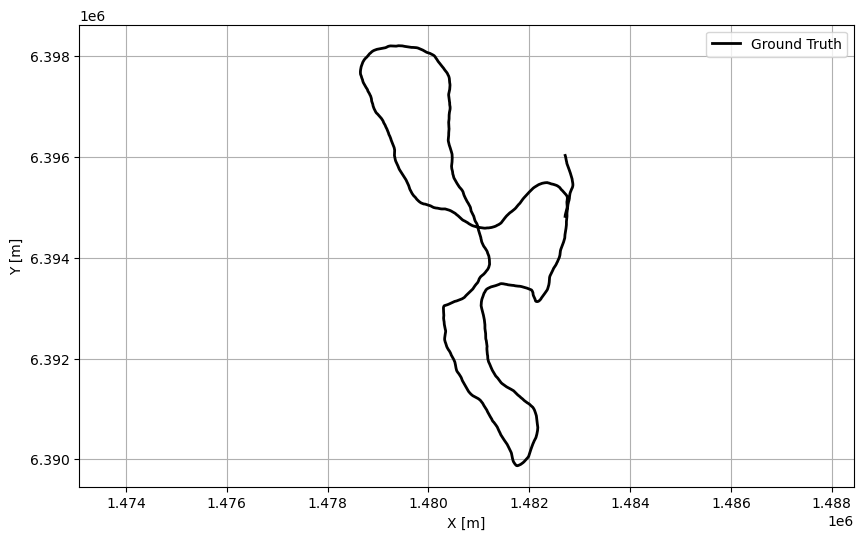

In [ ]:
TEST_SEQ_LEN = 1000
TEST_COUNT = 20
TEST_THRESH = 50.0
TEST_BATCH_SIZE = 256

test_dir = os.path.join(DATA_DIR, 'test_set')
os.makedirs(test_dir, exist_ok=True)

valid_x_list = []
valid_y_list = []

stats = {
    'generated': 0, 'dropped_bounds': 0, 'dropped_flat': 0,
    'dropped_filter_crash': 0, 'dropped_divergence': 0,
    'accepted': 0, 'avg_rmse_rejected': 0.0
}

pbar = tqdm(total=TEST_COUNT, desc="  -> TEST")
batch_counter = 0

while len(valid_x_list) < TEST_COUNT:
    batch_counter += 1
    x_batch = simulate_batch_ackermann(system_model, TEST_BATCH_SIZE, TEST_SEQ_LEN, real_speeds, real_yaws)
    stats['generated'] += TEST_BATCH_SIZE

    in_bounds = (
        (x_batch[:, :, 0].min(dim=1).values > system_model.min_x) &
        (x_batch[:, :, 0].max(dim=1).values < system_model.max_x) &
        (x_batch[:, :, 1].min(dim=1).values > system_model.min_y) &
        (x_batch[:, :, 1].max(dim=1).values < system_model.max_y)
    )
    x_cands = x_batch[in_bounds]
    if len(x_cands) == 0: 
        stats['dropped_bounds'] += TEST_BATCH_SIZE
        continue
    stats['dropped_bounds'] += (TEST_BATCH_SIZE - len(x_cands))
    
    try:
        batch_size_real = x_cands.shape[0]
        flat_x = x_cands.reshape(-1, 4)
        flat_y = system_model.measure(flat_x) 
        y_ideal = flat_y.reshape(batch_size_real, TEST_SEQ_LEN, 3)
        
        noise_std = torch.tensor([5.0, 1.0, 1.0], device=system_model.Ex0.device)
        white_noise = torch.randn_like(y_ideal) * noise_std
        
        y_with_noise = y_ideal + white_noise
        
        y_for_dataset = y_with_noise
        
    except Exception as e:
        print(f"Error: {e}")
        continue


    rmse_sum_rejected = 0
    rmse_count_rejected = 0
    
    for i in range(len(x_cands)):
        if len(valid_x_list) >= TEST_COUNT: break
        

        if torch.std(y_for_dataset[i, :, 0]) < 1.0: 
            stats['dropped_flat'] += 1
            continue
        
        try:
            x_gt = x_cands[i]
            

            res = filter_model.process_sequence(y_for_dataset[i], Ex0=x_gt[0], P0=system_model.P0)
            x_est = res['x_filtered']
            

            diff = x_est[:, :2] - x_gt[:, :2]
            rmse = torch.sqrt(torch.mean(torch.sum(diff**2, dim=1))).item()
            

            if rmse < TEST_THRESH:
                valid_x_list.append(x_gt.cpu())
                valid_y_list.append(y_for_dataset[i].cpu())
                stats['accepted'] += 1
                pbar.update(1)
            else:
                stats['dropped_divergence'] += 1
                rmse_sum_rejected += rmse
                rmse_count_rejected += 1
                
        except Exception:
            stats['dropped_filter_crash'] += 1
            continue

pbar.close()


test_data = {'x': torch.stack(valid_x_list), 'y': torch.stack(valid_y_list)}
torch.save(test_data, os.path.join(test_dir, 'test.pt'))

import matplotlib.pyplot as plt

x_vis = valid_x_list[0].numpy()
y_vis = valid_y_list[0].numpy()

plt.figure(figsize=(10, 6))
plt.plot(x_vis[:, 0], x_vis[:, 1], label='Ground Truth', color='black', linewidth=2)
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()